<a href="https://colab.research.google.com/github/gabgarar/FERMI_HESS_Analysis/blob/main/SED_AltasEnergias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Astrofísica de Altas Energías

# 1. Instanciar catálogos

In [1]:
!pip install gammapy

DOWNLOAD_DATASETS=True
if DOWNLOAD_DATASETS==True:
    !gammapy download datasets
import os
os.environ["GAMMAPY_DATA"] = "./gammapy-datasets/2.1"

from gammapy.catalog import SourceCatalog3FHL, SourceCatalogHGPS

# FERMI
fermi_cat = SourceCatalog3FHL()
print(fermi_cat.description)

# H.E.S.S.
hess_cat = SourceCatalogHGPS()
print(hess_cat.description)


INFO:gammapy.scripts.download:Downloading datasets from https://github.com/gammapy/gammapy-data/tarball/v2.1
279MB [00:21, 13.7MB/s]
INFO:gammapy.scripts.download:Extracting gammapy-datasets/2.1/datasets.tar.gz

*** You might want to declare GAMMAPY_DATA as a global env variable
export GAMMAPY_DATA=$PWD/gammapy-datasets/2.1

Or as part of your conda environment:
conda env config vars set GAMMAPY_DATA=$PWD/gammapy-datasets/2.1
conda activate gammapy-2.1

LAT third high-energy source catalog
H.E.S.S. Galactic plane survey (HGPS) source catalog


# 2. Cruzar repositorios de datos

In [2]:
from astropy import units as units
def naive_xmatch (x,y,min_distance=0.1*units.deg):
    """
    Args:
        x: lista con posiciones
        y: lista con posiciones
    Returns:
        xindex: lista de índices
        yindex: lista de índices
        dists: lista de distancias

    Devuelve los índeces de x e y que están a una distancia menor que 'min_distance' además de
    la distancia de separación. La devolución se hace en orden, esto es, el primer índice de la lista
    xindex está a una distancia menor que min_distance del primero de yindex y, éstos, están a una distancia
    que corresponde al primer elemento de la lista dists
    """
    xindex = []
    yindex = []
    dists = []
    for i in range(len(x)):
        d = x[i].separation(y)
        amin = d.argmin()
        dmin = d[amin]
        if dmin < min_distance:
            xindex.append(i)
            yindex.append(amin)
            dists.append(dmin)
    return xindex,yindex,dists


# Obtención de las posiciones.
## Crea dos variables llamadas fermi_pos y hess_pos que sean las coordenadas de los repectivos catálogos

from astropy.coordinates import SkyCoord
import astropy.units as u

fermi_pos = SkyCoord(fermi_cat.table["RAJ2000"],
                     fermi_cat.table["DEJ2000"],
                     unit=u.deg)

hess_pos = SkyCoord(hess_cat.table["RAJ2000"],
                    hess_cat.table["DEJ2000"],
                    unit=u.deg)

# rellena la siguiente celda para obtener los índices que corresponden a los mismos objetos en cada catalogo
xindex, yindex, dists = naive_xmatch(fermi_pos, hess_pos)


# 3. Escoger los datos de estudio

In [3]:
import astropy.units as u

# Creo una lista con información
matches = []

for i, j, d in zip(xindex, yindex, dists):
    deg = d.to(u.deg).value
    name = str(fermi_cat.table["Source_Name"][i])

    # clasificación básica por diversidad física
    if "1745" in name:
        typ = "Galactic Center"
    elif "1023" in name or "1119" in name or "1303" in name or "1640" in name:
        typ = "PWN"
    else:
        typ = "SNR/Other"

    matches.append((i, j, d, deg, typ))

# Ordenar por robustez (distancia creciente)
matches.sort(key=lambda x: x[3])

# Selección de 3 tipos diferentes
selected = []
types_used = set()

for m in matches:
    i, j, d, deg, typ = m

    if typ not in types_used:
        selected.append(m)
        types_used.add(typ)

    if len(selected) == 3:
        break

# impresión final
for i, j, d, deg, typ in selected:
    print("FERMI:", fermi_cat.table["Source_Name"][i])
    print("HESS:", hess_cat.table["Source_Name"][j])
    print("DIST:", d)
    print("TIPO:", typ)
    print("------")

FERMI: 3FHL J1826.2-1451 
HESS: HESS J1826-148
DIST: 0d00m21.66735381s
TIPO: SNR/Other
------
FERMI: 3FHL J1745.6-2900 
HESS: HESS J1745-290
DIST: 0d00m22.80861866s
TIPO: Galactic Center
------
FERMI: 3FHL J1303.0-6312e
HESS: HESS J1303-631
DIST: 0d00m25.19211844s
TIPO: PWN
------


# 4. Estudio por ajuste de ley de potencias + parabola

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from gammapy.datasets import FluxPointsDataset, Datasets
import gammapy.modeling.models as gmodels
from gammapy.modeling import Fit
import pandas as pd
import operator


# ============================================================
# Ajuste de modelo (acepta dataset único o lista de datasets)
# ============================================================
def fixModel(
    fds_model,
    AmpUnits,
    refUnits,
    modelName,
    appliedModels=["power", "logpar"],
    backend_model="minuit",
    freeze_map=None
):

    # Asegurar lista de datasets
    if isinstance(fds_model, list):
        joint_ds = Datasets(fds_model)
    else:
        joint_ds = Datasets([fds_model])

    model_list = []

    if "power" in appliedModels:
        power_model = gmodels.PowerLawSpectralModel(
            amplitude=AmpUnits,
            reference=refUnits,
            index=2.2
        )
        model_list.append(power_model)

    if "logpar" in appliedModels:
        logpar_model = gmodels.LogParabolaSpectralModel(
            amplitude=AmpUnits,
            reference=refUnits,
            alpha=2.0,
            beta=0.1
        )
        model_list.append(logpar_model)

    # ------------------------------------------------------------
    # COMBINAR MODELOS
    # ------------------------------------------------------------
    if len(model_list) == 1:
        spectral_model = model_list[0]
    else:
        # Suma de modelos
        spectral_model = model_list[0]
        for m in model_list[1:]:
            spectral_model = gmodels.CompoundSpectralModel(spectral_model, m, operator.add)

    # ------------------------------------------------------------
    # MAPEO DE ÍNDICES → NOMBRES (DINÁMICO)
    # ------------------------------------------------------------
    param_index_map = {}
    idx = 0

    if "power" in appliedModels:
        param_index_map.update({
            "amplitude_PL": idx,
            "index_PL": idx+1,
            "reference_PL": idx+2
        })
        idx += 3

    if "logpar" in appliedModels:
        param_index_map.update({
            "amplitude_LP": idx,
            "alpha_LP": idx+1,
            "beta_LP": idx+2,
            "reference_LP": idx+3
        })
        idx += 4

    # ------------------------------------------------------------
    # FREEZE MAP POR DEFECTO
    # ------------------------------------------------------------
    if freeze_map is None:
        freeze_map = {name: True for name in param_index_map.keys()}

    # ------------------------------------------------------------
    # APLICAR FREEZE_MAP
    # ------------------------------------------------------------
    for name, pidx in param_index_map.items():
        spectral_model.parameters[pidx].frozen = freeze_map.get(name, True)

    # SkyModel
    sky_model = gmodels.SkyModel(spectral_model=spectral_model, name=modelName)

    print("HOLA")

    # Ajuste
    joint_ds.models = sky_model
    result = Fit(backend=backend_model).run(datasets=joint_ds)


    print("---- VALORES AJUSTADOS ----")
    print(sky_model.spectral_model.parameters.to_table()[["name", "value", "error"]])


    return sky_model, joint_ds, result



# ============================================================
# Gráfico SED
# ============================================================
def showGraph(model, fds, ebounds, xLimits, yUnits, title, show_error=True, yLimits=None):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    plot_kwargs = {"ax": ax, "sed_type": "e2dnde"}

    ax.yaxis.set_units(u.Unit(yUnits))

    fds.data.plot(label=fds.name, color="darkblue", **plot_kwargs)
    model.spectral_model.plot(ebounds, label=model.name, color="blue", linewidth=0.5, **plot_kwargs)

    if show_error:
        model.spectral_model.plot_error(ebounds, color="#87CEEB", alpha=0.2, **plot_kwargs)

    ax.set_xlim(xLimits[0], xLimits[1])

    if yLimits is not None:
        ax.set_ylim(yLimits[0], yLimits[1])

    ax.set_title(title)
    ax.legend()

    plt.grid(
        True,
        which="both",
        linestyle="dashdot",
        linewidth=0.15,
        color="gray",
        alpha=0.5
    )
    plt.show()



def showGraph_multi(model, datasets, ebounds, xLimits, yUnits, title, show_error=True, yLimits=None):
    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111)
    plot_kwargs = {"ax": ax, "sed_type": "e2dnde"}

    # Unidad del eje Y
    ax.yaxis.set_units(u.Unit(yUnits))

    # Pintar cada dataset con un color distinto
    colors = ["blue", "red", "darkgreen", "purple"]

    for ds, col in zip(datasets, colors):
        ds.data.plot(label=ds.name, color=col, linewidth=0.5, **plot_kwargs)

    # Pintar modelo ajustado
    model.spectral_model.plot(ebounds, label=model.name, color="black", **plot_kwargs)

    # Banda de error opcional
    if show_error:
        model.spectral_model.plot_error(ebounds, color="#87CEEB", alpha=0.2, **plot_kwargs)

    if yLimits is not None:
        ax.set_ylim(yLimits[0], yLimits[1])

    ax.set_xlim(xLimits[0], xLimits[1])
    ax.set_title(title)
    ax.legend()

    plt.grid(
        True,
        which="both",
        linestyle="dashdot",
        linewidth=0.15,
        color="gray",
        alpha=0.5
    )

    plt.show()



# ============================================================
# Ajuste según catálogos (Fermi, HESS, etc.)
# ============================================================
def fix_model_given_catalog(catalogs, catNames, AmpUnits, refUnits, modelName, freeze_map, appliedModels, backend_model="minuit"):

    fds_models = []

    for cat, src_name in zip(catalogs, catNames):

        # Lista de nombres del catálogo
        names_clean_catalog = np.array([str(n).strip() for n in cat.table["Source_Name"]])

        # Buscar coincidencia exacta
        matches = np.where(np.char.find(names_clean_catalog, src_name.strip()) >= 0)[0]
        if len(matches) == 0:
            raise ValueError(f"No se encontró la fuente '{src_name}' en el catálogo.")
        cat_idx = matches[0]
        print(f"Índice en {src_name}: {cat_idx}")

        # Construcción del dataset
        fds = FluxPointsDataset(data=cat[cat_idx].flux_points, name=cat[cat_idx].name)
        print(f"Dataset usado: {fds.name}")

        fds_models.append(fds)

    # Ajustar modelo conjunto
    sky_model, joint_ds, result = fixModel(fds_models, AmpUnits, refUnits, modelName, backend_model=backend_model, freeze_map=freeze_map, appliedModels=appliedModels)

    return sky_model, joint_ds, result



# ============================================================
# FUNCIÓN PARA GENERAR TABLA DE PARÁMETROS ESPECTRALES
# ============================================================
def build_spectral_table(models, ref_energies, labels):

    rows = []

    for model, refE, label in zip(models, ref_energies, labels):

        spec = model.spectral_model

        # Valores por defecto
        spectral_index = spectral_index_err = np.nan
        beta_val = beta_err = np.nan
        amp = amp_err = np.nan
        spectral_index_label = "Índice Espectral"

        # Initialize actual_amplitude_unit to a default or None
        actual_amplitude_unit = u.Unit('') # Default empty unit

        # ============================================================
        # CASO 1: PowerLaw
        # ============================================================
        if isinstance(spec, gmodels.PowerLawSpectralModel):

            spectral_index = spec.index.value
            spectral_index_err = spec.index.error
            spectral_index_label = "Índice Espectral (Γ)"

            amp = spec.amplitude.value
            amp_err = spec.amplitude.error
            actual_amplitude_unit = spec.amplitude.unit

        # ============================================================
        # CASO 2: LogParabola
        # ============================================================
        elif isinstance(spec, gmodels.LogParabolaSpectralModel):

            spectral_index = spec.alpha.value
            spectral_index_err = spec.alpha.error
            beta_val = spec.beta.value
            beta_err = spec.beta.error
            spectral_index_label = "Índice Espectral (α)"

            amp = spec.amplitude.value
            amp_err = spec.amplitude.error
            actual_amplitude_unit = spec.amplitude.unit

        # ============================================================
        # CASO 3: CompoundSpectralModel (PowerLaw + LogParabola)
        # ============================================================
        elif isinstance(spec, gmodels.CompoundSpectralModel):

            # Parámetros LP dentro del modelo compuesto
            # Based on the fixModel output, the parameters are ordered as:
            # 0: index (PowerLaw), 1: amplitude (PowerLaw), 2: reference (PowerLaw)
            # 3: amplitude (LogParabola), 4: reference (LogParabola)
            # 5: alpha (LogParabola), 6: beta (LogParabola)
            amp = spec.parameters[3].value # LogParabola amplitude
            amp_err = spec.parameters[3].error
            actual_amplitude_unit = spec.parameters[3].unit

            spectral_index = spec.parameters[5].value   # alpha
            spectral_index_err = spec.parameters[5].error
            beta_val = spec.parameters[6].value         # beta
            beta_err = spec.parameters[6].error

            spectral_index_label = "Índice Espectral (α)"

        # ============================================================
        # Normalización de amplitud
        # ============================================================
        display_unit_label = "Norm. (×1e-12)"

        if actual_amplitude_unit == u.Unit("cm-2 s-1 TeV-1"):
            display_unit_label = "Norm. (×1e-12 TeV⁻¹ cm⁻² s⁻¹)"
        elif actual_amplitude_unit == u.Unit("cm-2 s-1 GeV-1"):
            display_unit_label = "Norm. (×1e-12 GeV⁻¹ cm⁻² s⁻¹)"

        amp /= 1e-12
        amp_err /= 1e-12

        # ============================================================
        # Construcción de la fila
        # ============================================================
        row_data = {
            "Modelo / Ajuste": label,
            "Energía de Ref.": refE,
            spectral_index_label: f"{spectral_index:.3f} \u00B1 {spectral_index_err:.3f}",
            display_unit_label: f"{amp:.4f} \u00B1 {amp_err:.4f}",
            "Beta (\u03B2)": f"{beta_val:.3f} \u00B1 {beta_err:.3f}" if not np.isnan(beta_val) else "N/A"
        }

        rows.append(row_data)

    return pd.DataFrame(rows)



# ============================================================
# FUNCIÓN PARA GENERAR TABLA DE PARÁMETROS ESPECTRALES
# ============================================================


def get_spectral_index(spec):
    # PowerLaw
    if isinstance(spec, gmodels.PowerLawSpectralModel):
        return spec.index.value

    # LogParabola
    if isinstance(spec, gmodels.LogParabolaSpectralModel):
        return spec.alpha.value

    # CompoundSpectralModel (PowerLaw + LogParabola)
    if isinstance(spec, gmodels.CompoundSpectralModel):
        # alpha está en el parámetro 5 (corrected index)
        return spec.parameters[5].value

    raise ValueError("Modelo espectral no reconocido")

def analyzeRes(
    fermi_sky_model, fermi_sky_model_res, fermi_ds,
    hess_sky_model, hess_sky_model_res, hess_ds,
    join_sky_model, join_sky_model_res, join_ds
):

    # Estadísticos
    stat_fermi = fermi_sky_model_res.total_stat
    stat_hess  = hess_sky_model_res.total_stat
    stat_total = join_sky_model_res.total_stat

    val_stat_fermi = getattr(stat_fermi, 'value', stat_fermi)
    val_stat_hess  = getattr(stat_hess,  'value', stat_hess)
    val_stat_total = getattr(stat_total, 'value', stat_total)

    # Índices espectrales
    gamma_f = get_spectral_index(fermi_sky_model.spectral_model)
    gamma_h = get_spectral_index(hess_sky_model.spectral_model)
    gamma_j = get_spectral_index(join_sky_model.spectral_model)

    # Contribuciones
    porcentaje_fermi = (val_stat_fermi / val_stat_total) * 100 if val_stat_total != 0 else 0
    porcentaje_hess  = (val_stat_hess  / val_stat_total) * 100 if val_stat_total != 0 else 0

    # ============================================================
    # CÁLCULO DE χ² REDUCIDO (VERSIÓN CORRECTA)
    # ============================================================

    # Número de puntos (FluxPointsDataset → FluxPoints → to_table())
    n_points_fermi = len(fermi_ds.data.to_table())
    n_points_hess  = len(hess_ds.data.to_table())
    n_points_join  = sum(len(ds.data.to_table()) for ds in join_ds)

    # Parámetros libres del modelo conjunto
    n_free_params = sum(1 for p in join_sky_model.spectral_model.parameters if not p.frozen)

    # Grados de libertad
    ndof_fermi = n_points_fermi - n_free_params
    ndof_hess  = n_points_hess  - n_free_params
    ndof_join  = n_points_join  - n_free_params

    # χ² reducido
    chi2_red_fermi = val_stat_fermi / ndof_fermi if ndof_fermi > 0 else float("nan")
    chi2_red_hess  = val_stat_hess  / ndof_hess  if ndof_hess  > 0 else float("nan")
    chi2_red_join  = val_stat_total / ndof_join  if ndof_join  > 0 else float("nan")

    # ============================================================
    # TABLA FINAL
    # ============================================================

    data_diag = {
        "Métrica de Control": [
            "Estadístico Fermi (GeV)",
            "Estadístico H.E.S.S. (TeV)",
            "Estadístico Total (χ²)",
            "χ² reducido Fermi",
            "χ² reducido H.E.S.S.",
            "χ² reducido Conjunto",
            "Índice Espectral Fermi",
            "Índice Espectral H.E.S.S.",
            "Índice Espectral Conjunto"
        ],
        "Valor Obtenido": [
            f"{val_stat_fermi:.4f}",
            f"{val_stat_hess:.4f}",
            f"{val_stat_total:.4f}",
            f"{chi2_red_fermi:.3f}",
            f"{chi2_red_hess:.3f}",
            f"{chi2_red_join:.3f}",
            f"{gamma_f:.2f}",
            f"{gamma_h:.2f}",
            f"{gamma_j:.2f}"
        ],
        "Contexto / Contribución": [
            f"{porcentaje_fermi:.2f}% del total",
            f"{porcentaje_hess:.2f}% del total",
            "Bondad global del ajuste",
            "≈1 ajuste razonable; <<1 sobreajuste",
            "≈1 ajuste razonable; <<1 sobreajuste",
            "≈1 ajuste razonable; <<1 sobreajuste",
            "Espectro duro",
            "Espectro blando",
            "Pendiente conjunta"
        ]
    }

    return pd.DataFrame(data_diag)

# 5. Estudio de los siguientes objetos:

*  3FHL J1303.0-6312e (PWN)
*  3FHL J1826.2-1451 (SNR/Other)
*  3FHL J1745.6-2900 (Galactic Center)





## 5.1. SNR/Other

## 5.1.1. Ajuste Fermi, HESS y cjto

Índice en 3FHL J1826.2-1451: 1222
Dataset usado: 3FHL J1826.2-1451
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.2000e+00 0.000e+00
amplitude 5.0000e-13 0.000e+00
reference 1.0000e+00 0.000e+00
amplitude 5.0000e-13 0.000e+00
reference 1.5074e+00 6.994e-01
    alpha 2.3826e+00 2.172e-01
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)
/usr/local/lib/python3.12/dist-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in log
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


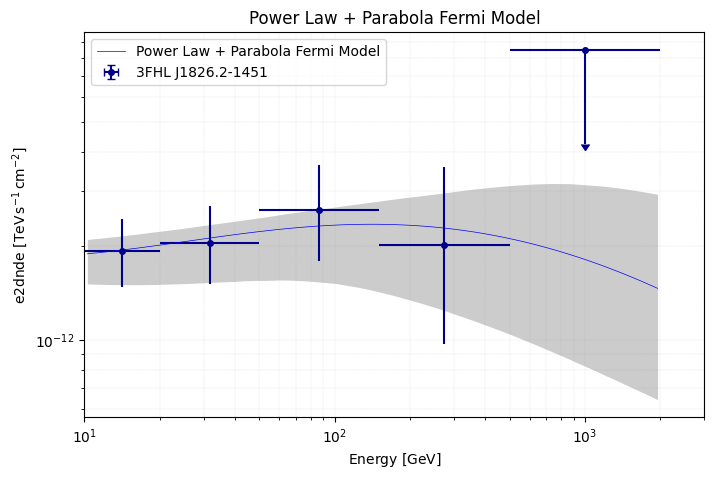

Índice en HESS J1826-148: 56
Dataset usado: HESS J1826-148
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
amplitude 1.0000e-12 0.000e+00
reference 1.0848e+00 3.804e-02
    alpha 2.1575e+00 8.979e-02
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


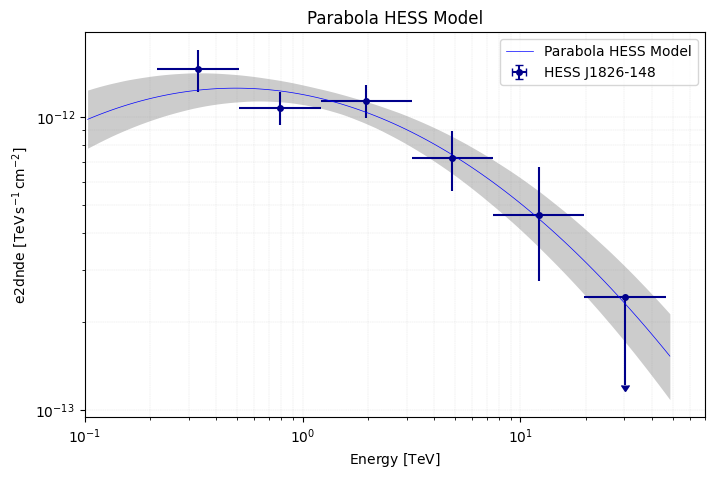

Índice en HESS J1826-148: 56
Dataset usado: HESS J1826-148
Índice en 3FHL J1826.2-1451: 1222
Dataset usado: 3FHL J1826.2-1451
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.2000e+00 0.000e+00
amplitude 5.0000e-13 0.000e+00
reference 1.0000e+00 0.000e+00
amplitude 5.0000e-13 0.000e+00
reference 1.1335e+00 6.892e-02
    alpha 2.3960e+00 1.374e-01
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


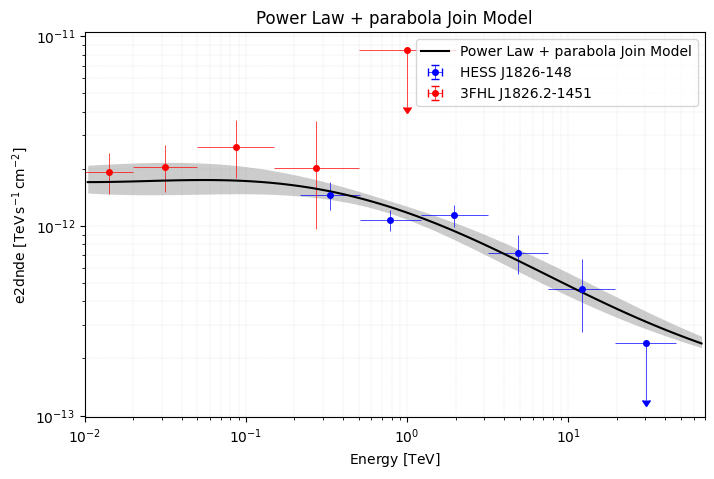

In [6]:
freeze_map = {
    "amplitude_PL": True,
    "index_PL": True,
    "reference_PL": True,
    "amplitude_LP": True,
    "alpha_LP": False,
    "beta_LP": False,
    "reference_LP": True
}

# ============================
# Ajuste Fermi
# ============================


fermi_name = ["3FHL J1826.2-1451"]   # Debe ser lista
fermi_model_name = "Power Law + Parabola Fermi Model"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    modelName=fermi_model_name,
    freeze_map=freeze_map,
    appliedModels=["power", "logpar"],
)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

freeze_map_hess = {
    "amplitude_LP": True,
    "alpha_LP": False,
    "beta_LP": False,
    "reference_LP": True
}

hess_name = ["HESS J1826-148"]   # También debe ser lista
hess_model_name = "Parabola HESS Model"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1", # Cuidado cuando es solo un modelo
    refUnits="1 TeV",
    modelName=hess_model_name,
    freeze_map=freeze_map_hess,
    appliedModels=["logpar"],
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1826-148", "3FHL J1826.2-1451"]
join_model_name = "Power Law + parabola Join Model"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    modelName=join_model_name,
    freeze_map=freeze_map,
    appliedModels=["power", "logpar"],
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.1.2. Tabla de resultados

In [7]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["1 TeV", "1 TeV", "1 TeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (α),Norm. (×1e-12 TeV⁻¹ cm⁻² s⁻¹),Beta (β)
0,Solo Fermi-LAT (GeV),1 TeV,2.383 ± 0.217,0.5000 ± 0.0000,0.100 ± 0.000
1,Solo H.E.S.S. (TeV),1 TeV,2.158 ± 0.090,1.0000 ± 0.0000,0.100 ± 0.000
2,Conjunto (Banda Ancha),1 TeV,2.396 ± 0.137,0.5000 ± 0.0000,0.100 ± 0.000



## 5.1.3. Análisis de residuos

In [8]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(
    fermi_sky_model,
    fermi_sky_model_res,
    fds[0],

    hess_sky_model,
    hess_sky_model_res,
    hds[0],
    join_sky_model,
    join_sky_model_res,
    join_ds
)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Estadístico Fermi (GeV),0.1556,2.97% del total
1,Estadístico H.E.S.S. (TeV),2.4483,46.68% del total
2,Estadístico Total (χ²),5.2454,Bondad global del ajuste
3,χ² reducido Fermi,0.052,≈1 ajuste razonable; <<1 sobreajuste
4,χ² reducido H.E.S.S.,0.612,≈1 ajuste razonable; <<1 sobreajuste
5,χ² reducido Conjunto,0.583,≈1 ajuste razonable; <<1 sobreajuste
6,Índice Espectral Fermi,2.38,Espectro duro
7,Índice Espectral H.E.S.S.,2.16,Espectro blando
8,Índice Espectral Conjunto,2.40,Pendiente conjunta


## 5.2. PWN



Índice en 3FHL J1303.0-6312e: 835
Dataset usado: 3FHL J1303.0-6312e
HOLA
---- VALORES AJUSTADOS ----
   name      value      error  
--------- ----------- ---------
    index  2.2000e+00 0.000e+00
amplitude -3.7428e-12 2.213e-12
reference  1.0000e+00 0.000e+00
amplitude  5.0000e-13 0.000e+00
reference  2.3803e+00 1.990e-01
    alpha  2.7683e+00 9.211e-02
     beta  1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


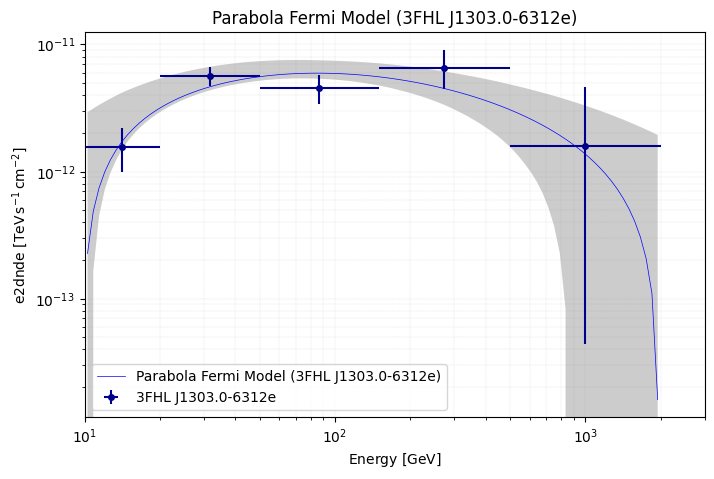

Índice en HESS J1303-631: 8
Dataset usado: HESS J1303-631
HOLA
---- VALORES AJUSTADOS ----
   name      value      error  
--------- ----------- ---------
    index  2.2000e+00 0.000e+00
amplitude -2.2803e-12 1.003e-12
reference  1.0000e+00 0.000e+00
amplitude  5.0000e-13 0.000e+00
reference  3.6845e+00 2.064e-01
    alpha  2.3290e+00 1.780e-02
     beta  1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


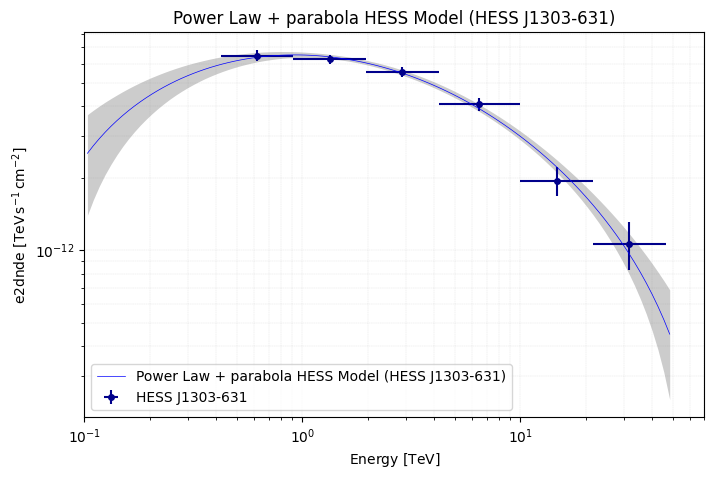

Índice en HESS J1303-631: 8
Dataset usado: HESS J1303-631
Índice en 3FHL J1303.0-6312e: 835
Dataset usado: 3FHL J1303.0-6312e
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.2000e+00 0.000e+00
amplitude 3.8584e-14 2.554e-13
reference 1.0000e+00 0.000e+00
amplitude 5.0000e-13 0.000e+00
reference 3.1641e+00 6.861e-02
    alpha 2.3519e+00 2.293e-02
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


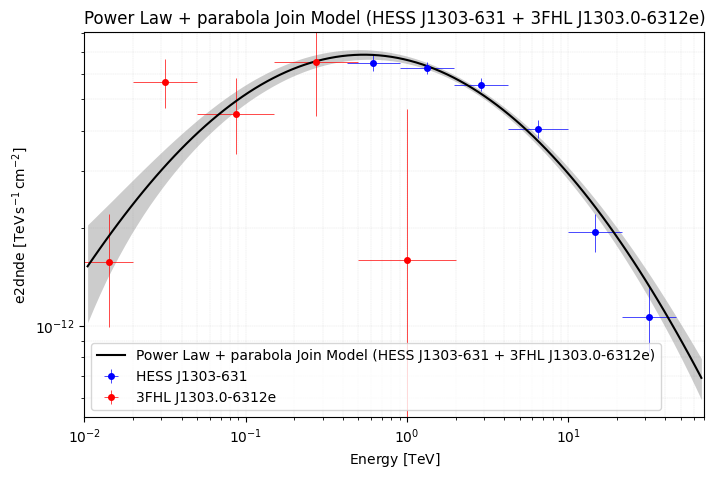

In [9]:
freeze_map = {
    "amplitude_PL": True,
    "index_PL": False,
    "reference_PL": True,
    "amplitude_LP": True,
    "alpha_LP": False,
    "beta_LP": False,
    "reference_LP": True
}

# ============================
# Ajuste Fermi
# ============================

fermi_name = ["3FHL J1303.0-6312e"]   # Debe ser lista
fermi_model_name = "Parabola Fermi Model (3FHL J1303.0-6312e)"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map,
    modelName=fermi_model_name,
    appliedModels=["power", "logpar"],

)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

hess_name = ["HESS J1303-631"]   # También debe ser lista
hess_model_name = "Power Law + parabola HESS Model (HESS J1303-631)"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map,
    modelName=hess_model_name,
    appliedModels=["power", "logpar"],
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1303-631", "3FHL J1303.0-6312e"]
join_model_name = "Power Law + parabola Join Model (HESS J1303-631 + 3FHL J1303.0-6312e)"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map,
    modelName=join_model_name,
    appliedModels=["power", "logpar"],
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.2.2. Tabla de resultados



In [10]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["1 TeV", "1 TeV", "1 TeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (α),Norm. (×1e-12 TeV⁻¹ cm⁻² s⁻¹),Beta (β)
0,Solo Fermi-LAT (GeV),1 TeV,2.768 ± 0.092,0.5000 ± 0.0000,0.100 ± 0.000
1,Solo H.E.S.S. (TeV),1 TeV,2.329 ± 0.018,0.5000 ± 0.0000,0.100 ± 0.000
2,Conjunto (Banda Ancha),1 TeV,2.352 ± 0.023,0.5000 ± 0.0000,0.100 ± 0.000


## 5.2.3. Análisis de residuos

In [11]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(
    fermi_sky_model,
    fermi_sky_model_res,
    fds[0],
    hess_sky_model,
    hess_sky_model_res,
    hds[0],
    join_sky_model,
    join_sky_model_res,
    join_ds
)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Estadístico Fermi (GeV),3.3197,16.82% del total
1,Estadístico H.E.S.S. (TeV),2.2152,11.22% del total
2,Estadístico Total (χ²),19.7421,Bondad global del ajuste
3,χ² reducido Fermi,1.660,≈1 ajuste razonable; <<1 sobreajuste
4,χ² reducido H.E.S.S.,0.738,≈1 ajuste razonable; <<1 sobreajuste
5,χ² reducido Conjunto,2.468,≈1 ajuste razonable; <<1 sobreajuste
6,Índice Espectral Fermi,2.77,Espectro duro
7,Índice Espectral H.E.S.S.,2.33,Espectro blando
8,Índice Espectral Conjunto,2.35,Pendiente conjunta


## 5.3. Galactic Center

## 5.3.1. Ajuste Fermi, HESS y cjto

Índice en 3FHL J1745.6-2900: 1169
Dataset usado: 3FHL J1745.6-2900
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
amplitude 1.0000e-12 0.000e+00
reference 6.4509e-01 8.950e-02
    alpha 3.3733e+00 1.053e-01
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


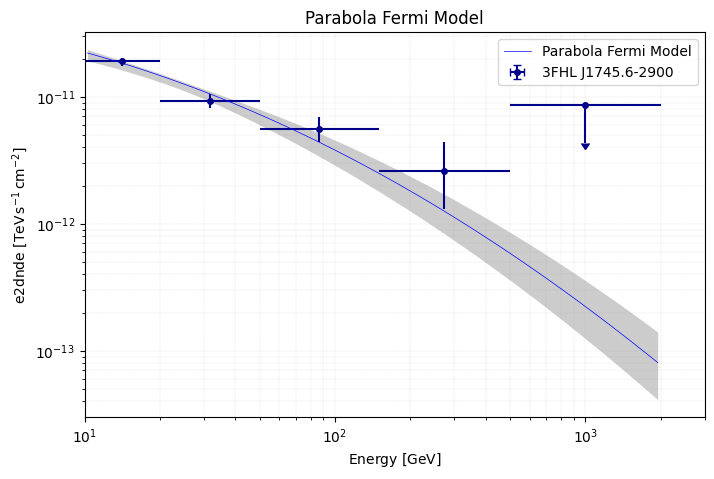

Índice en HESS J1745-290: 40
Dataset usado: HESS J1745-290
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.6935e+00 8.814e-02
amplitude 5.0000e-13 0.000e+00
reference 1.0000e+00 0.000e+00
amplitude 7.5004e-12 3.345e-12
reference 5.0002e-01 1.020e-01
    alpha 2.0000e+00 0.000e+00
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


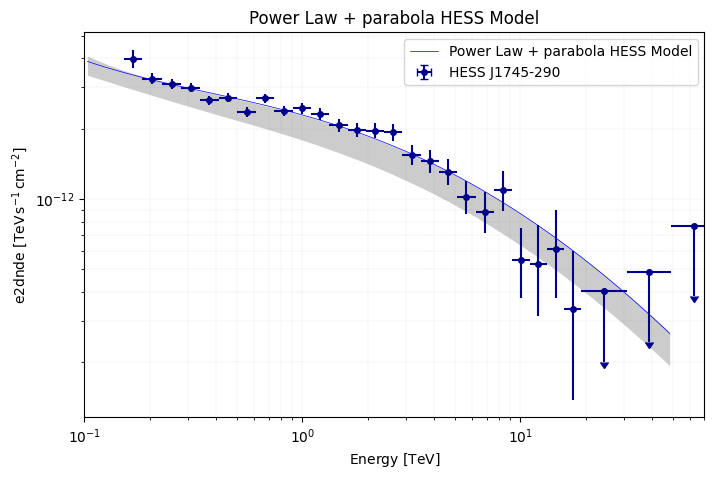

Índice en HESS J1745-290: 40
Dataset usado: HESS J1745-290
Índice en 3FHL J1745.6-2900: 1169
Dataset usado: 3FHL J1745.6-2900
HOLA
---- VALORES AJUSTADOS ----
   name     value      error  
--------- ---------- ---------
    index 2.8354e+00 1.631e-02
amplitude 5.0000e-13 0.000e+00
reference 1.0000e+00 0.000e+00
amplitude 4.0015e-12 8.996e-13
reference 6.6485e-01 7.174e-02
    alpha 2.0000e+00 0.000e+00
     beta 1.0000e-01 0.000e+00


/usr/local/lib/python3.12/dist-packages/gammapy/maps/region/ndmap.py:154: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(
/usr/local/lib/python3.12/dist-packages/gammapy/modeling/models/spectral.py:650: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(energy.center, flux.quantity[:, 0, 0], **kwargs)


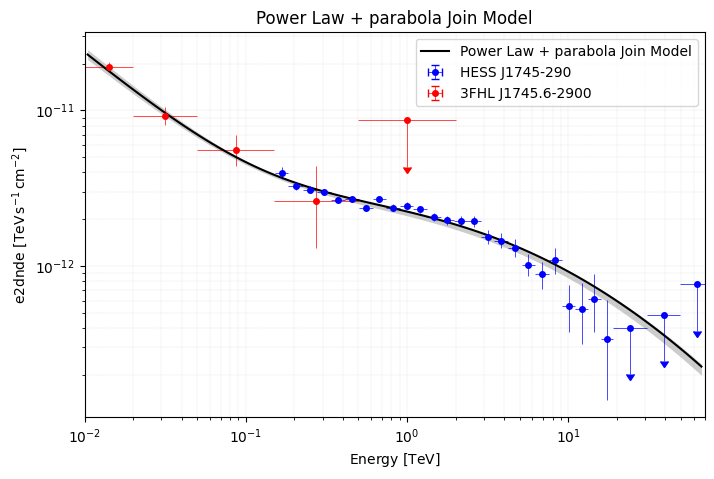

In [12]:
freeze_map = {
    "amplitude_PL": False,
    "index_PL": True,
    "reference_PL": True,
    "amplitude_LP": False,
    "alpha_LP": False,
    "beta_LP": True,
    "reference_LP": True
}

# ============================
# Ajuste Fermi
# ============================

freeze_map_fermi = {

    "amplitude_LP": True,
    "alpha_LP": False,
    "beta_LP": False,
    "reference_LP": True
}

fermi_name = ["3FHL J1745.6-2900"]   # Debe ser lista
fermi_model_name = "Parabola Fermi Model"

# Ajustar modelo para Fermi
fermi_sky_model, fds, fermi_sky_model_res = fix_model_given_catalog(
    catalogs=[fermi_cat],
    catNames=fermi_name,
    AmpUnits="1e-12 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map_fermi,
    modelName=fermi_model_name,
    appliedModels=["logpar"],
)

# Pintar la gráfica para Fermi
showGraph(
    model=fermi_sky_model,
    fds=fds[0],
    ebounds=[10, 2000] * u.GeV,
    xLimits=[10, 3000] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=fermi_model_name
)



# ============================
# Ajuste H.E.S.S.
# ============================

hess_name = ["HESS J1745-290"]   # También debe ser lista
hess_model_name = "Power Law + parabola HESS Model"

# Ajustar modelo para HESS
hess_sky_model, hds, hess_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat],
    catNames=hess_name,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map,
    modelName=hess_model_name,
    appliedModels=["power", "logpar"],
)

# Pintar la gráfica para HESS
showGraph(
    model=hess_sky_model,
    fds=hds[0],
    ebounds=[0.1, 50] * u.TeV,
    xLimits=[100, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=hess_model_name
)

# ============================
# Ajuste conjunto Fermi + HESS
# ============================

join_names = ["HESS J1745-290", "3FHL J1745.6-2900"]
join_model_name = "Power Law + parabola Join Model"

join_sky_model, join_ds, join_sky_model_res = fix_model_given_catalog(
    catalogs=[hess_cat, fermi_cat],
    catNames=join_names,
    AmpUnits="5e-13 cm-2 s-1 TeV-1",
    refUnits="1 TeV",
    freeze_map=freeze_map,
    modelName=join_model_name,
    appliedModels=["power", "logpar"],
)


# ============================
# Gráfica conjunta
# ============================

showGraph_multi(
    model=join_sky_model,
    datasets=join_ds,                # <-- aquí van Fermi + HESS juntos
    ebounds=[10, 7e4] * u.GeV,       # <-- Rango energético conjunto (10 GeV → 70 TeV)
    xLimits=[10, 7e4] * u.GeV,
    yUnits="TeV cm-2 s-1",
    title=join_model_name
)


## 5.3.2. Tabla de resultados

In [13]:
# ============================
# TABLA DE RESULTADOS
# ============================

df_results = build_spectral_table(
    models=[fermi_sky_model, hess_sky_model, join_sky_model],
    ref_energies=["1 TeV", "1 TeV", "1 TeV"],
    labels=["Solo Fermi-LAT (GeV)", "Solo H.E.S.S. (TeV)", "Conjunto (Banda Ancha)"]
)

df_results

,Modelo / Ajuste,Energía de Ref.,Índice Espectral (α),Norm. (×1e-12 TeV⁻¹ cm⁻² s⁻¹),Beta (β)
0,Solo Fermi-LAT (GeV),1 TeV,3.373 ± 0.105,1.0000 ± 0.0000,0.100 ± 0.000
1,Solo H.E.S.S. (TeV),1 TeV,2.000 ± 0.000,7.5004 ± 3.3452,0.100 ± 0.000
2,Conjunto (Banda Ancha),1 TeV,2.000 ± 0.000,4.0015 ± 0.8996,0.100 ± 0.000


## 5.3.3. Análisis de residuos



In [14]:
# ============================
# ANÁLISIS DE RESTOS
# ============================

analyzeRes(
    fermi_sky_model,
    fermi_sky_model_res,
    fds[0],

    hess_sky_model,
    hess_sky_model_res,
    hds[0],
    join_sky_model,
    join_sky_model_res,
    join_ds
)

,Métrica de Control,Valor Obtenido,Contexto / Contribución
0,Estadístico Fermi (GeV),3.0998,9.35% del total
1,Estadístico H.E.S.S. (TeV),28.0937,84.73% del total
2,Estadístico Total (χ²),33.1553,Bondad global del ajuste
3,χ² reducido Fermi,1.550,≈1 ajuste razonable; <<1 sobreajuste
4,χ² reducido H.E.S.S.,1.124,≈1 ajuste razonable; <<1 sobreajuste
5,χ² reducido Conjunto,1.105,≈1 ajuste razonable; <<1 sobreajuste
6,Índice Espectral Fermi,3.37,Espectro duro
7,Índice Espectral H.E.S.S.,2.00,Espectro blando
8,Índice Espectral Conjunto,2.00,Pendiente conjunta
